# Static EEG Data Wrangling

This notebook builds, analyzes, trains and evaluates a machine learning model on a combined static dataset from CHB-MIT and Siena scalp EEG datasets

## Notebook goals

- Configure dataset and preprocessing settings.
- Run the static dataset-building pipeline script.
- Load the generated dataset outputs for inspection and EDA.
- Select EEG features for model train
- Train and evaluate a Random Forest model for seizure prediction.


## Running Instructions

This notebook works in both **VS Code** and **Google Colab**.

### Local (VS Code)
- Run all cells from top to bottom.

### Google Colab
- Upload one of the following files to Google Colab:
  - `master_eeg_dataset.parquet`
  - `master_eeg_dataset.csv`
- Then **skip to Step 2: Load the Dataset**

## Requirements and Outputs

- `DATASET_ROOT_OVERRIDE` from the configuration cell below.

The dataset root must contain the folders `chbmit/` and `siena/`.

Outputs from this notebook:

- `master_eeg_dataset.parquet`
- `master_eeg_dataset.csv` 
- `master_eeg_dataset_X.npy` 
- `master_eeg_dataset_y.npy`
- `master_eeg_dataset_meta.csv`


## Imports

In [1]:
import numpy as np
import pandas as pd
import subprocess
import sys
import os

from pathlib import Path
from sklearn.model_selection import GroupShuffleSplit
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
)
from sklearn.metrics import precision_score, recall_score, f1_score
    

## Configuration

This section keeps the settings most people are likely to tweak.

Inputs: Dataset root override, set preprocessing and epoch parameters.

Output for the next step: notebook configuration variables used by the bootstrap and workflow cells.


In [2]:
# Explicit dataset root. Change this to where you store the datasets
DATASET_ROOT_OVERRIDE = None

# Static dataset configuration
EPOCH_DURATION_SEC = 10.0
EPOCH_OVERLAP_SEC = 0.0
TARGET_SFREQ = 256
PREICTAL_HORIZON_SEC = 600
POSTICTAL_EXCLUSION_SEC = 1800
INTERICTAL_GAP_SEC = 300

## Step 1: Build the Dataframe

This step puts both static datasets into a dataframe, by running the pipeline script named build_static_dataset

In [60]:
repo_root = Path.cwd()
output_root = repo_root / "artifacts" / "static"
output_root.mkdir(parents=True, exist_ok=True)

cmd = [
    sys.executable,
    "-m",
    "scripts.build_static_dataset",
    "--output-root",
    str(output_root),
    "--epoch-duration",
    str(EPOCH_DURATION_SEC),
    "--epoch-overlap",
    str(EPOCH_OVERLAP_SEC),
    "--preictal-horizon-sec",
    str(PREICTAL_HORIZON_SEC),
    "--postictal-exclusion-sec",
    str(POSTICTAL_EXCLUSION_SEC),
    "--interictal-gap-sec",
    str(INTERICTAL_GAP_SEC),
]

if DATASET_ROOT_OVERRIDE is not None:
    cmd += ["--dataset-root", str(DATASET_ROOT_OVERRIDE)]

print("Running command:")
print(" ".join(cmd))

env = os.environ.copy()
env["PYTHONPATH"] = str(repo_root / "src")

result = subprocess.run(
    cmd,
    cwd=repo_root,
    env=env,
    text=True,
    capture_output=True,
)

print("STDOUT:\n")
print(result.stdout)

if result.stderr:
    print("STDERR:\n")
    print(result.stderr)

if result.returncode != 0:
    raise RuntimeError(f"Dataset build failed with exit code {result.returncode}")

print("\nBuild completed.")
print(f"Outputs saved in: {output_root}")
print("Files:")
for p in sorted(output_root.iterdir()):
    print(" -", p.name)

Running command:
/Users/lukeblevins/Developer/School/Machine Learning and Data Science/eeg-Spr2026-CSCI7090/.venv/bin/python -m scripts.build_static_dataset --output-root /Users/lukeblevins/Developer/School/Machine Learning and Data Science/eeg-Spr2026-CSCI7090/artifacts/static --epoch-duration 10.0 --epoch-overlap 0.0 --preictal-horizon-sec 600 --postictal-exclusion-sec 1800 --interictal-gap-sec 300
STDOUT:

[DEBUG] About to load annotations
[DEBUG] Reading Siena annotation file: /Users/lukeblevins/Developer/School/Machine Learning and Data Science/eeg-Spr2026-CSCI7090/data/siena/pn00/Seizures-list-PN00.txt
[DEBUG] Parsed 5 Siena seizure intervals from /Users/lukeblevins/Developer/School/Machine Learning and Data Science/eeg-Spr2026-CSCI7090/data/siena/pn00/Seizures-list-PN00.txt
[DEBUG] Total Siena annotation EDF entries loaded: 5
[DEBUG] Finished loading annotations
[DEBUG] Total annotation keys loaded: 47
[DEBUG] Total EDF files found: 2
[DEBUG] Next EDF path: /Users/lukeblevins/De

## Step 2: Load the Dataset

This cell loads the preprocessed EEG dataset from either CSV or parquet file into a DataFrame. This step also checks for missing and duplicate values.

In [3]:
possible_parquet_paths = [
    Path("artifacts/static/master_eeg_dataset.parquet"),
    Path("master_eeg_dataset.parquet"),
]

possible_csv_paths = [
    Path("artifacts/static/master_eeg_dataset.csv"),
    Path("master_eeg_dataset.csv"),
]

parquet_path = next((p for p in possible_parquet_paths if p.exists()), None)
csv_path = next((p for p in possible_csv_paths if p.exists()), None)

if parquet_path is not None:
    print("Loading dataset from:", parquet_path)
    df_all = pd.read_parquet(parquet_path)

elif csv_path is not None:
    print("Loading dataset from:", csv_path)
    try:
        df_all = pd.read_csv(csv_path)
    except Exception:
        df_all = pd.read_csv(csv_path, engine="python", on_bad_lines="skip")

else:
    raise FileNotFoundError(
        "Could not find master_eeg_dataset.parquet or master_eeg_dataset.csv.\n"
        "Place the dataset in 'artifacts/static/' or upload it directly to the working directory."
    )

print("Shape:", df_all.shape)
print("Columns:", df_all.columns.tolist())
print("Number of missing values:", df_all.isna().sum().sum())
print("Number of duplicate rows:", df_all.duplicated().sum())
display(df_all.groupby("dataset").head(5))

Loading dataset from: artifacts\static\master_eeg_dataset.parquet
Shape: (354478, 50)
Columns: ['source_type', 'dataset', 'subject_id', 'session_id', 'record_id', 'edf_path', 'source_file_name', 'epoch_index', 'window_start_sec', 'window_end_sec', 'duration_sec', 'label', 'target', 'n_seizures_in_file', 'feature_version', 'channel_schema', 'channel_signature', 'annotation_source', 'mean', 'std', 'min', 'max', 'range', 'median', 'iqr', 'energy', 'rms', 'abs_mean', 'peak_to_peak', 'skewness', 'kurtosis', 'line_length', 'zero_crossing_rate', 'hjorth_activity', 'hjorth_mobility', 'hjorth_complexity', 'delta_power', 'theta_power', 'alpha_power', 'beta_power', 'gamma_power', 'rel_delta_power', 'rel_theta_power', 'rel_alpha_power', 'rel_beta_power', 'rel_gamma_power', 'spectral_entropy', 'n_channels', 'n_samples', 'sfreq']
Number of missing values: 0
Number of duplicate rows: 0


,source_type,dataset,subject_id,session_id,record_id,edf_path,source_file_name,epoch_index,window_start_sec,window_end_sec,...,gamma_power,rel_delta_power,rel_theta_power,rel_alpha_power,rel_beta_power,rel_gamma_power,spectral_entropy,n_channels,n_samples,sfreq
0,static,chbmit,chb01,chb01_01,chbmit:chb01:chb01_01:epoch_000000,D:\chbmit\chb01\chb01_01.edf,chb01_01.edf,0,0.0,10.0,...,5.951810e-11,0.684505,0.132845,0.034744,0.093101,0.054805,2.369413,22,2560,256.0
1,static,chbmit,chb01,chb01_01,chbmit:chb01:chb01_01:epoch_000001,D:\chbmit\chb01\chb01_01.edf,chb01_01.edf,1,10.0,20.0,...,1.179723e-10,0.483129,0.164479,0.044867,0.190880,0.116644,2.909574,22,2560,256.0
2,static,chbmit,chb01,chb01_01,chbmit:chb01:chb01_01:epoch_000002,D:\chbmit\chb01\chb01_01.edf,chb01_01.edf,2,20.0,30.0,...,6.217961e-11,0.625582,0.172360,0.045401,0.094285,0.062372,2.494199,22,2560,256.0
3,static,chbmit,chb01,chb01_01,chbmit:chb01:chb01_01:epoch_000003,D:\chbmit\chb01\chb01_01.edf,chb01_01.edf,3,30.0,40.0,...,5.291522e-11,0.449282,0.193469,0.056498,0.194554,0.106196,3.000437,22,2560,256.0
4,static,chbmit,chb01,chb01_01,chbmit:chb01:chb01_01:epoch_000004,D:\chbmit\chb01\chb01_01.edf,chb01_01.edf,4,40.0,50.0,...,2.651843e-11,0.636435,0.201558,0.045322,0.080237,0.036447,2.352539,22,2560,256.0
329893,static,siena,pn00,pn00-1,siena:pn00:pn00-1:epoch_000000,D:\siena\PN00\PN00-1.edf,PN00-1.edf,0,0.0,10.0,...,1.174882e-10,0.187164,0.243058,0.190130,0.353267,0.026381,3.216134,35,2560,256.0
329894,static,siena,pn00,pn00-1,siena:pn00:pn00-1:epoch_000182,D:\siena\PN00\PN00-1.edf,PN00-1.edf,182,1820.0,1830.0,...,5.644738e-11,0.205761,0.248835,0.188863,0.340609,0.015932,3.149940,35,2560,256.0
329895,static,siena,pn00,pn00-1,siena:pn00:pn00-1:epoch_000183,D:\siena\PN00\PN00-1.edf,PN00-1.edf,183,1830.0,1840.0,...,5.012047e-11,0.223477,0.253285,0.181694,0.325855,0.015689,3.119462,35,2560,256.0
329896,static,siena,pn00,pn00-1,siena:pn00:pn00-1:epoch_000184,D:\siena\PN00\PN00-1.edf,PN00-1.edf,184,1840.0,1850.0,...,5.905626e-11,0.186833,0.246565,0.196157,0.354815,0.015630,3.178202,35,2560,256.0
329897,static,siena,pn00,pn00-1,siena:pn00:pn00-1:epoch_000185,D:\siena\PN00\PN00-1.edf,PN00-1.edf,185,1850.0,1860.0,...,6.146244e-11,0.181985,0.240998,0.197504,0.363305,0.016208,3.195070,35,2560,256.0


## Step 3: Visualizations

Inline EDA plots drawn directly from `df_all`. Each code cell produces one visualization; the markdown cell below each figure states the key observation for this project.

In [4]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
import seaborn as sns
from scipy.stats import zscore

PALETTE = {"interictal": "#4C72B0", "preictal": "#DD8452"}
LABEL_ORDER = ["interictal", "preictal"]
DS_PALETTE = {"chbmit": "#4e79a7", "siena": "#59a14f"}
FEATURES = [
    "std",
    "energy",
    "rms",
    "abs_mean",
    "line_length",
    "spectral_entropy",
    "hjorth_activity",
    "delta_power",
]

chb = df_all[df_all["dataset"] == "chbmit"].copy()
siena_df = df_all[df_all["dataset"] == "siena"].copy()
n_preictal = (df_all["label"] == "preictal").sum()
print(f"Setup complete — n_preictal={n_preictal}, total rows={len(df_all)}")

Setup complete — n_preictal=2231, total rows=354478


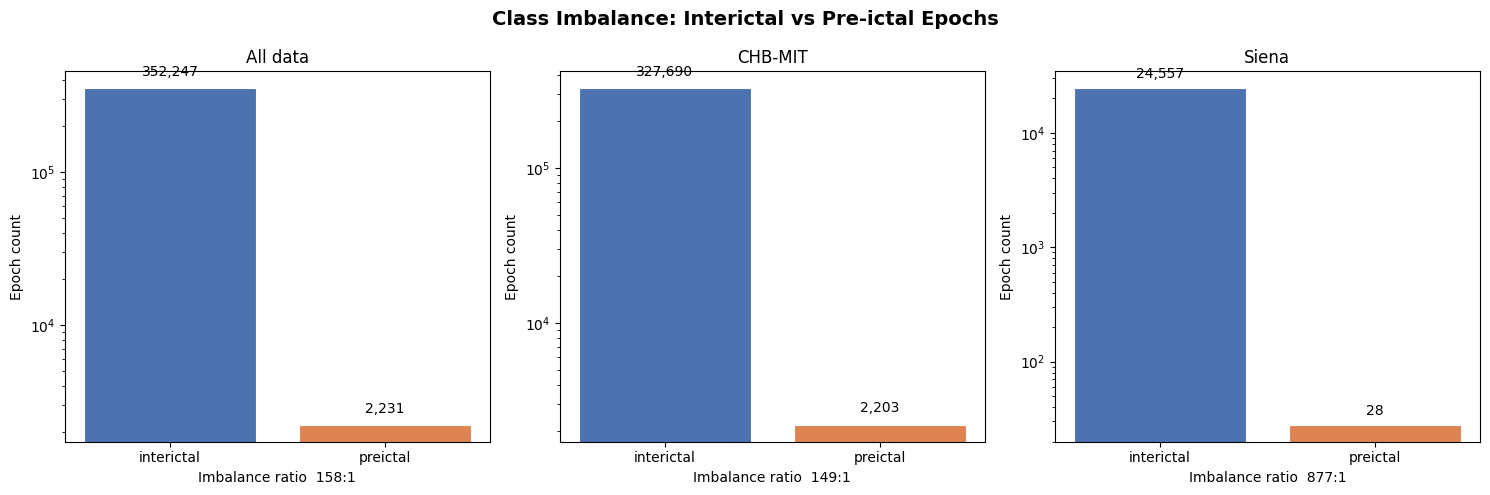

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle(
    "Class Imbalance: Interictal vs Pre-ictal Epochs", fontsize=14, fontweight="bold"
)

for ax, (title, subset) in zip(
    axes, [("All data", df_all), ("CHB-MIT", chb), ("Siena", siena_df)]
):
    counts = subset["label"].value_counts().reindex(LABEL_ORDER, fill_value=0)
    bars = ax.bar(
        counts.index,
        counts.values,
        color=[PALETTE[l] for l in counts.index],
        edgecolor="white",
        linewidth=0.8,
    )
    ax.set_yscale("log")
    ax.set_title(title, fontsize=12)
    ax.set_ylabel("Epoch count")
    for bar, val in zip(bars, counts.values):
        if val > 0:
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() * 1.15,
                f"{val:,}",
                ha="center",
                va="bottom",
                fontsize=10,
            )
    ratio = counts["interictal"] / max(counts.get("preictal", 1), 1)
    ax.set_xlabel(f"Imbalance ratio  {ratio:.0f}:1", fontsize=10)

plt.tight_layout()
plt.show()

The dataset is severely imbalanced — interictal epochs vastly outnumber pre-ictal ones in both sources — which reflects the rarity of seizure precursors in raw EEG and justifies the `class_weight='balanced_subsample'` setting used in training.

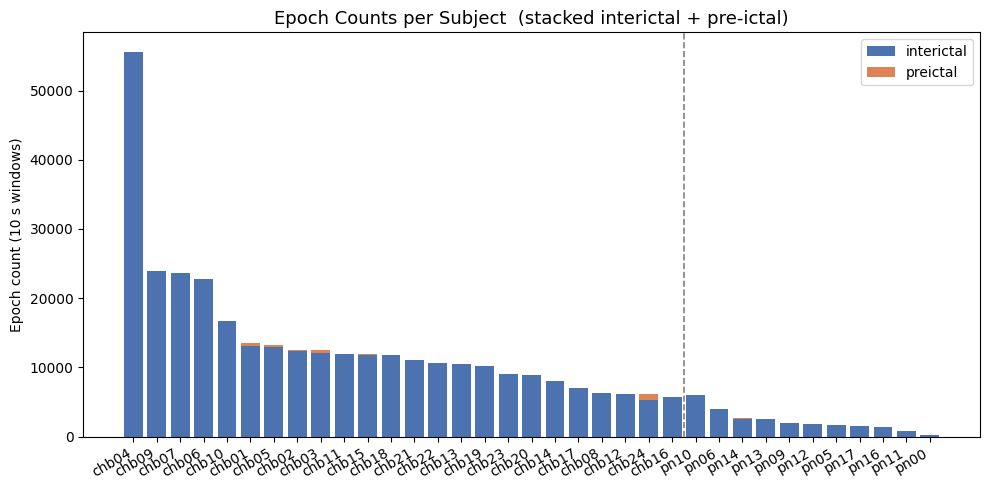

In [6]:
subj_label = (
    df_all.groupby(["dataset", "subject_id", "label"])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)
if "preictal" not in subj_label.columns:
    subj_label["preictal"] = 0
if "interictal" not in subj_label.columns:
    subj_label["interictal"] = 0
subj_label["total"] = subj_label["interictal"] + subj_label["preictal"]
subj_label = subj_label.sort_values(["dataset", "total"], ascending=[True, False])

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(subj_label))
ax.bar(x, subj_label["interictal"], color=PALETTE["interictal"], label="interictal")
ax.bar(
    x,
    subj_label["preictal"],
    bottom=subj_label["interictal"],
    color=PALETTE["preictal"],
    label="preictal",
)
ax.set_xticks(x)
ax.set_xticklabels(subj_label["subject_id"], rotation=30, ha="right", fontsize=10)
ax.set_ylabel("Epoch count (10 s windows)")
ax.set_title("Epoch Counts per Subject  (stacked interictal + pre-ictal)", fontsize=13)
ax.legend()
n_chb = (subj_label["dataset"] == "chbmit").sum()
if 0 < n_chb < len(subj_label):
    ax.axvline(n_chb - 0.5, color="gray", linestyle="--", linewidth=1.2)
plt.tight_layout()
plt.show()

The visualization shows the number of interictal and preictal epochs per subject in both the CHB-MIT and Siena datasets. The class imbalance can also clearly be seen with the majority falling into the interictal category.

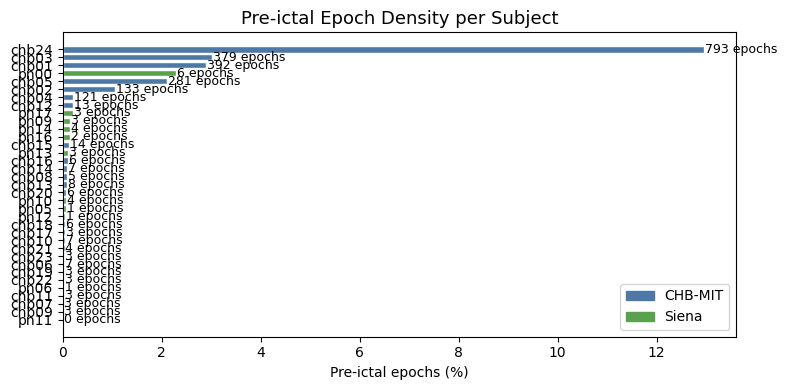

In [7]:
grp = df_all.groupby("subject_id")["target"].agg(["sum", "count"])
grp["pct"] = grp["sum"] / grp["count"] * 100
grp["dataset"] = df_all.groupby("subject_id")["dataset"].first()
grp = grp.sort_values("pct", ascending=True)

fig, ax = plt.subplots(figsize=(8, 4))
colors = grp["dataset"].map(DS_PALETTE)
bars = ax.barh(grp.index, grp["pct"], color=colors, edgecolor="white")
ax.set_xlabel("Pre-ictal epochs (%)")
ax.set_title("Pre-ictal Epoch Density per Subject", fontsize=13)
for bar, (_, row) in zip(bars, grp.iterrows()):
    ax.text(
        bar.get_width() + 0.02,
        bar.get_y() + bar.get_height() / 2,
        f'{int(row["sum"])} epochs',
        va="center",
        fontsize=9,
    )
patches = [
    mpatches.Patch(color=DS_PALETTE["chbmit"], label="CHB-MIT"),
    mpatches.Patch(color=DS_PALETTE["siena"], label="Siena"),
]
ax.legend(handles=patches)
plt.tight_layout()
plt.show()

This visualization shows the percentage of preictal epochs per patient in the CHB-MIT and Siena datasets. The majority of patients contain very few preictal samples, emphasizing the significant class imbalance between interictal and preictal epochs.

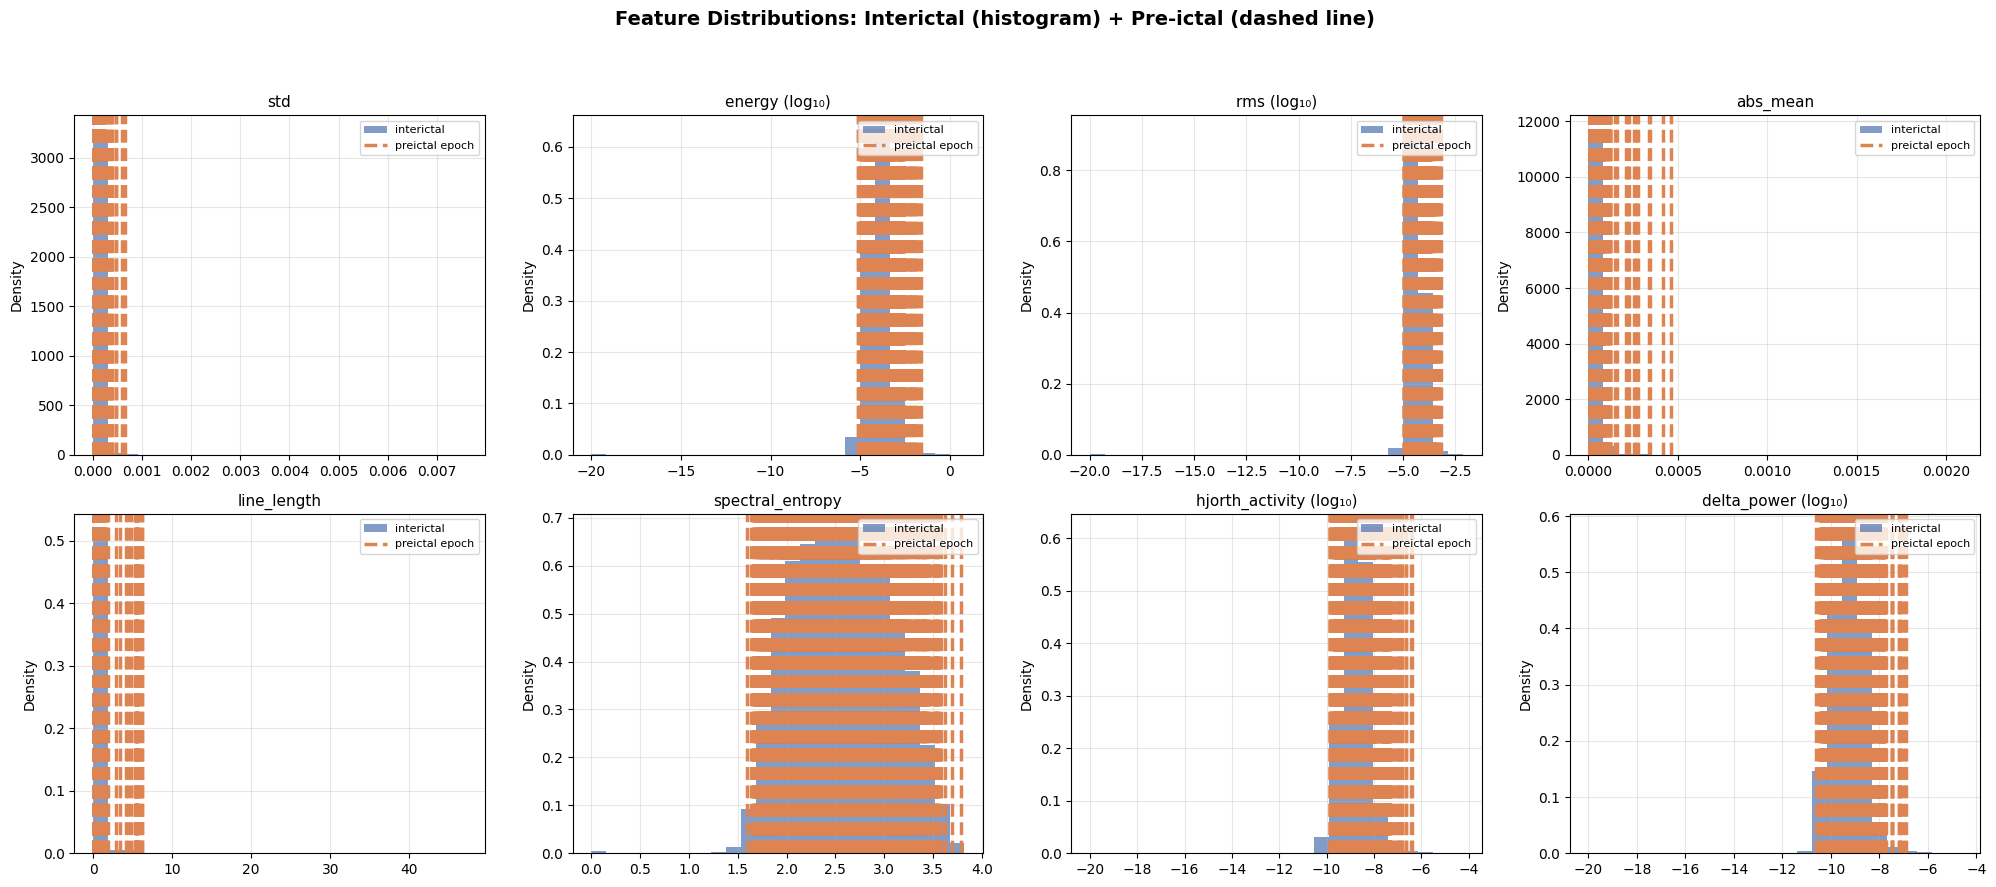

In [8]:
log_features = {"energy", "rms", "hjorth_activity", "delta_power"}

fig, axes = plt.subplots(2, 4, figsize=(20, 9))
fig.suptitle(
    "Feature Distributions: Interictal (histogram) + Pre-ictal (dashed line)",
    fontsize=14,
    fontweight="bold",
)

for ax, feat in zip(axes.flat, FEATURES):
    intr_vals = df_all.loc[df_all["label"] == "interictal", feat].dropna()
    if feat in log_features:
        intr_vals = np.log10(intr_vals.clip(lower=1e-20))
    ax.hist(
        intr_vals,
        bins=25,
        color=PALETTE["interictal"],
        alpha=0.7,
        density=True,
        label="interictal",
    )

    pre_vals = pd.Series(dtype=float)
    if n_preictal >= 1:
        pre_vals = df_all.loc[df_all["label"] == "preictal", feat].dropna()
        if feat in log_features:
            pre_vals = np.log10(pre_vals.clip(lower=1e-20))
        for v in pre_vals:
            ax.axvline(
                v,
                color=PALETTE["preictal"],
                linewidth=2.5,
                linestyle="--",
            )

    ax.set_title(feat + (" (log₁₀)" if feat in log_features else ""), fontsize=11)
    ax.set_ylabel("Density")
    handles, labels = ax.get_legend_handles_labels()
    if n_preictal >= 1 and not pre_vals.empty:
        handles.append(
            Line2D([0], [0], color=PALETTE["preictal"], linewidth=2.5, linestyle="--")
        )
        labels.append("preictal epoch")
    ax.legend(handles, labels, fontsize=8, loc="upper right")
    ax.grid(True, alpha=0.3)

plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()

The dashed line marks the single pre-ictal epoch's position within each interictal distribution; it falls in the upper-amplitude tail for std, energy, and rms but within the bulk for spectral features — with only one labeled precursor, no feature yet cleanly separates the classes.

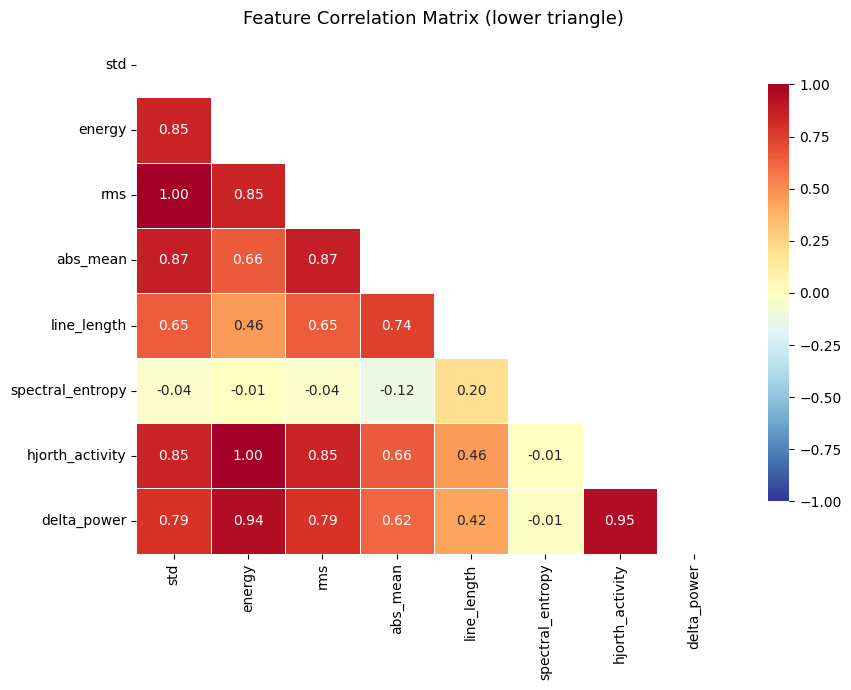

In [9]:
corr = df_all[FEATURES].corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="RdYlBu_r",
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    ax=ax,
    cbar_kws={"shrink": 0.8},
)
ax.set_title("Feature Correlation Matrix (lower triangle)", fontsize=13)
plt.tight_layout()
plt.show()

`std`, `energy`, `rms`, and `hjorth_activity` cluster near r=1, forming a redundant amplitude group; retaining just one representative from this cluster (e.g. `std`) would reduce multicollinearity without losing discriminative information.

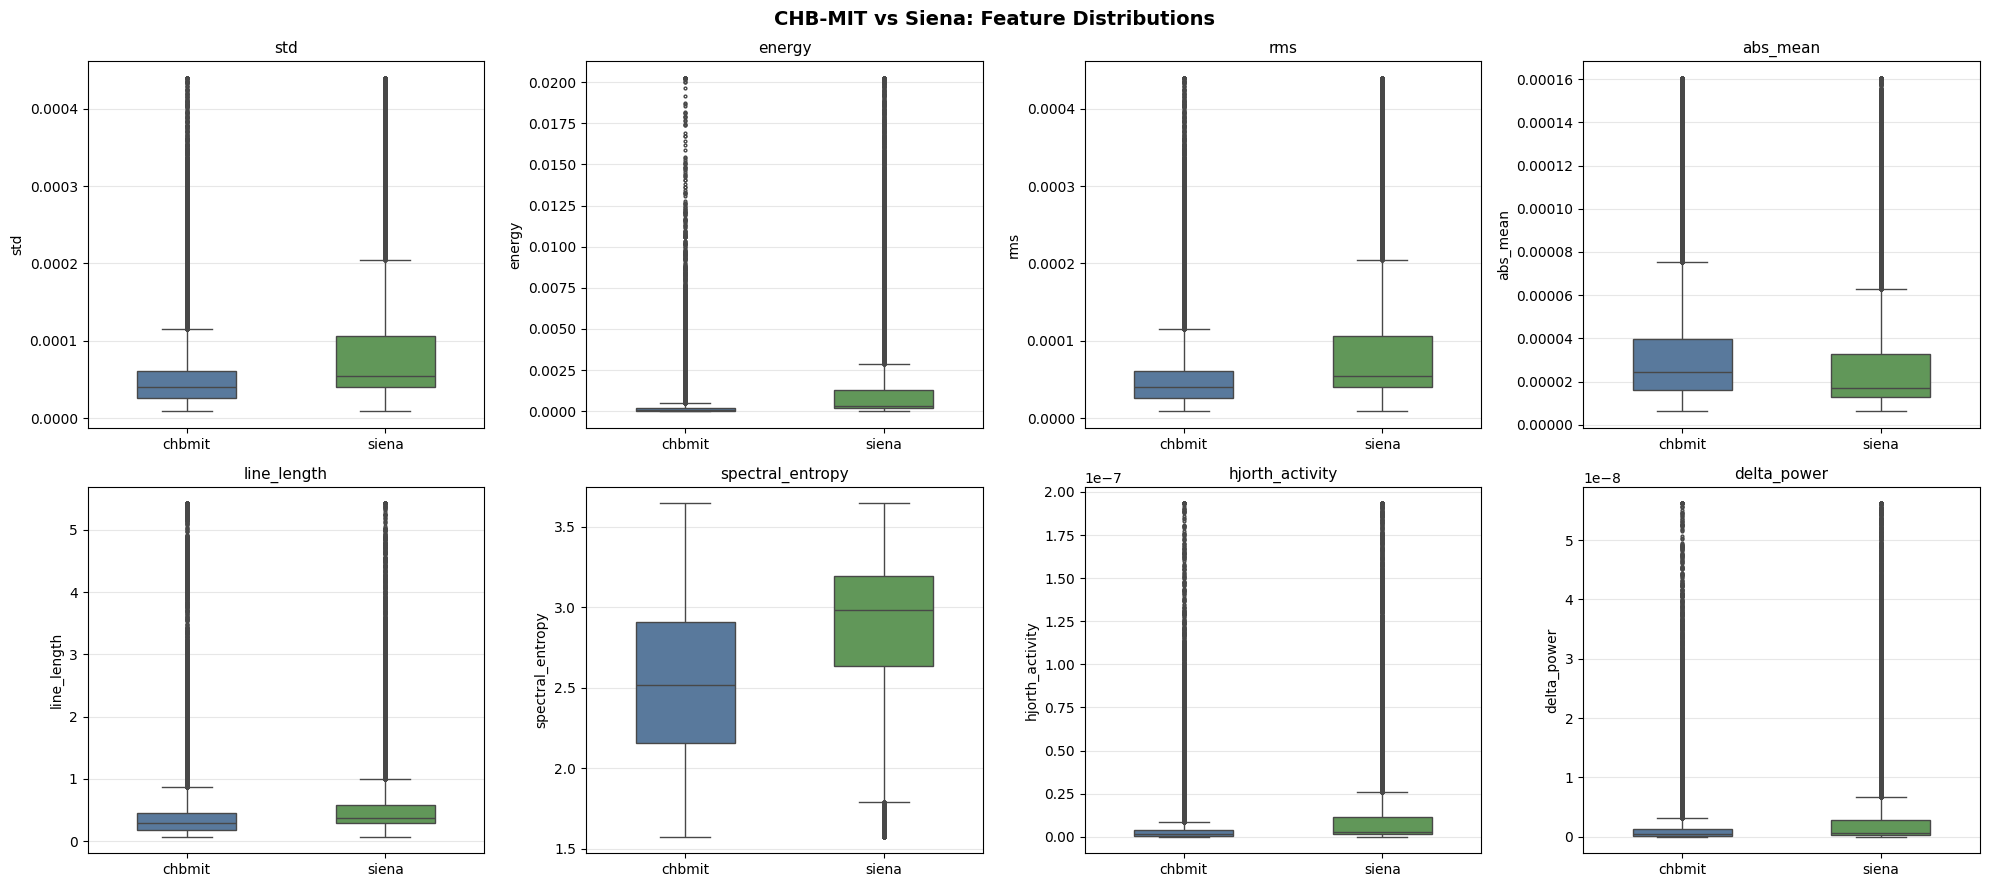

In [10]:
plot_df = df_all[FEATURES + ["dataset"]].copy()
for feat in FEATURES:
    lo, hi = plot_df[feat].quantile([0.005, 0.995])
    plot_df[feat] = plot_df[feat].clip(lo, hi)

fig, axes = plt.subplots(2, 4, figsize=(20, 9))
fig.suptitle("CHB-MIT vs Siena: Feature Distributions", fontsize=14, fontweight="bold")
for ax, feat in zip(axes.flat, FEATURES):
    sns.boxplot(
        data=plot_df,
        x="dataset",
        y=feat,
        palette=DS_PALETTE,
        hue="dataset",
        ax=ax,
        width=0.5,
        fliersize=2,
        legend=False,
    )
    ax.set_title(feat, fontsize=11)
    ax.set_xlabel("")
    ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

Siena's amplitude-related features (energy, rms) are systematically higher than CHB-MIT's, likely due to electrode type, recording hardware, and patient state differences; any model trained on one dataset will need normalization or domain adaptation to generalize to the other.

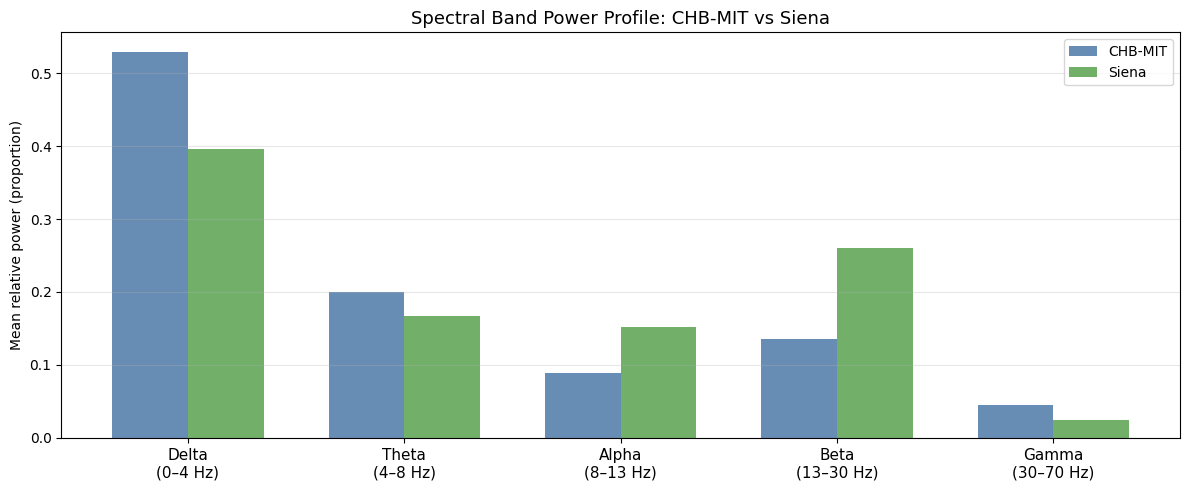

In [11]:
rel_band_cols = [
    "rel_delta_power",
    "rel_theta_power",
    "rel_alpha_power",
    "rel_beta_power",
    "rel_gamma_power",
]
band_names = [
    "Delta\n(0–4 Hz)",
    "Theta\n(4–8 Hz)",
    "Alpha\n(8–13 Hz)",
    "Beta\n(13–30 Hz)",
    "Gamma\n(30–70 Hz)",
]

band_means = df_all.groupby("dataset")[rel_band_cols].mean()

x = np.arange(len(rel_band_cols))
width = 0.35
fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(
    x - width / 2,
    band_means.loc["chbmit"],
    width,
    label="CHB-MIT",
    color=DS_PALETTE["chbmit"],
    alpha=0.85,
)
ax.bar(
    x + width / 2,
    band_means.loc["siena"],
    width,
    label="Siena",
    color=DS_PALETTE["siena"],
    alpha=0.85,
)
ax.set_xticks(x)
ax.set_xticklabels(band_names, fontsize=11)
ax.set_ylabel("Mean relative power (proportion)")
ax.set_title("Spectral Band Power Profile: CHB-MIT vs Siena", fontsize=13)
ax.legend()
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

CHB-MIT recordings are strongly delta-dominated (~59% of spectral power), consistent with pediatric drowsy or sleep EEG, while Siena shows a flatter profile with greater beta activity — this cross-dataset spectral divergence is a key confound that frequency-band features must account for.

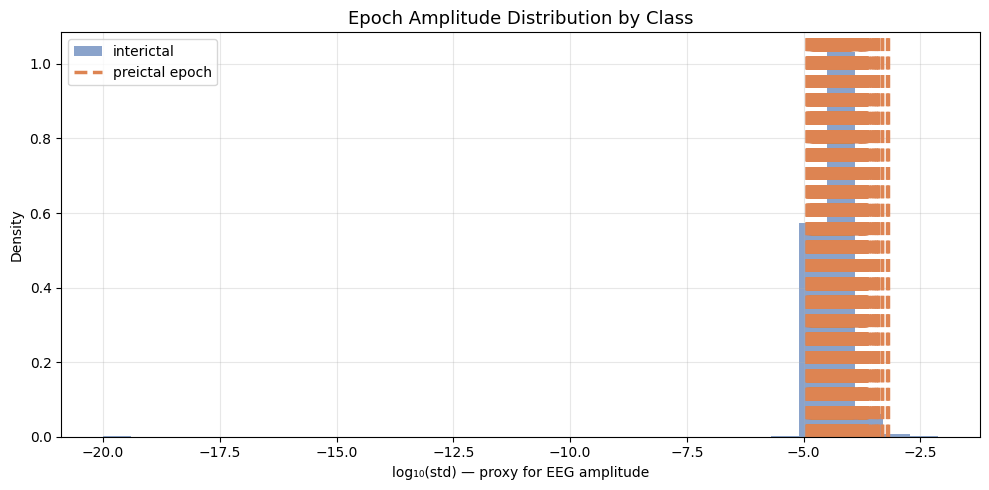

In [15]:
intr_log_std = np.log10(
    df_all[df_all["label"] == "interictal"]["std"].clip(lower=1e-20)
)
pre_log_std = np.log10(df_all[df_all["label"] == "preictal"]["std"].clip(lower=1e-20))

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(
    intr_log_std,
    bins=30,
    alpha=0.65,
    color=PALETTE["interictal"],
    label="interictal",
    density=True,
)
if len(pre_log_std) >= 1:
    for v in pre_log_std:
        ax.axvline(
            v,
            color=PALETTE["preictal"],
            linewidth=2.5,
            linestyle="--",
        )
ax.set_xlabel("log₁₀(std) — proxy for EEG amplitude")
ax.set_ylabel("Density")
ax.set_title("Epoch Amplitude Distribution by Class", fontsize=13)
handles, labels = ax.get_legend_handles_labels()
if len(pre_log_std) >= 1:
    handles.append(
        Line2D([0], [0], color=PALETTE["preictal"], linewidth=2.5, linestyle="--")
    )
    labels.append("preictal epoch")
ax.legend(handles, labels)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

The pre-ictal epoch's amplitude sits in the upper tail of the interictal distribution, consistent with a subtle pre-seizure EEG elevation, but a single sample is far too few to treat this as a reliable discriminative signature.

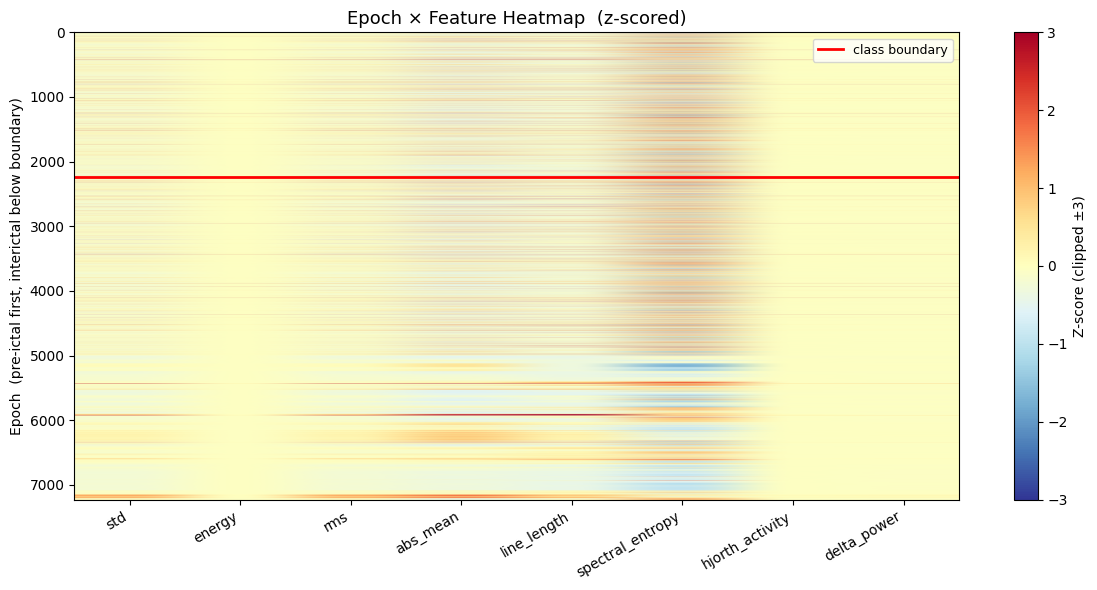

In [16]:
pre_sub = df_all[df_all["label"] == "preictal"][FEATURES + ["label"]]
intr_sub = df_all[df_all["label"] == "interictal"][FEATURES + ["label"]].sample(
    min(5000, (df_all["label"] == "interictal").sum()), random_state=42
)
plot_df = pd.concat([pre_sub, intr_sub]).sort_values("label")

mat = plot_df[FEATURES].apply(zscore).clip(-3, 3).values
n_preictal_rows = (plot_df["label"] == "preictal").sum()

fig, ax = plt.subplots(figsize=(12, 6))
im = ax.imshow(mat, aspect="auto", cmap="RdYlBu_r", vmin=-3, vmax=3)
plt.colorbar(im, ax=ax, label="Z-score (clipped ±3)")
ax.set_xticks(range(len(FEATURES)))
ax.set_xticklabels(FEATURES, rotation=30, ha="right")
ax.set_ylabel("Epoch  (pre-ictal first, interictal below boundary)")
ax.set_title("Epoch × Feature Heatmap  (z-scored)", fontsize=13)
ax.axhline(n_preictal_rows - 0.5, color="red", linewidth=2, label="class boundary")
ax.legend(loc="upper right", fontsize=9)
plt.tight_layout()
plt.show()

The heatmap rows sort pre-ictal above the red boundary and interictal below; the single pre-ictal row shows elevated delta power and energy relative to the median interictal epoch, but the pattern is only interpretable once many more pre-ictal examples populate the top region.

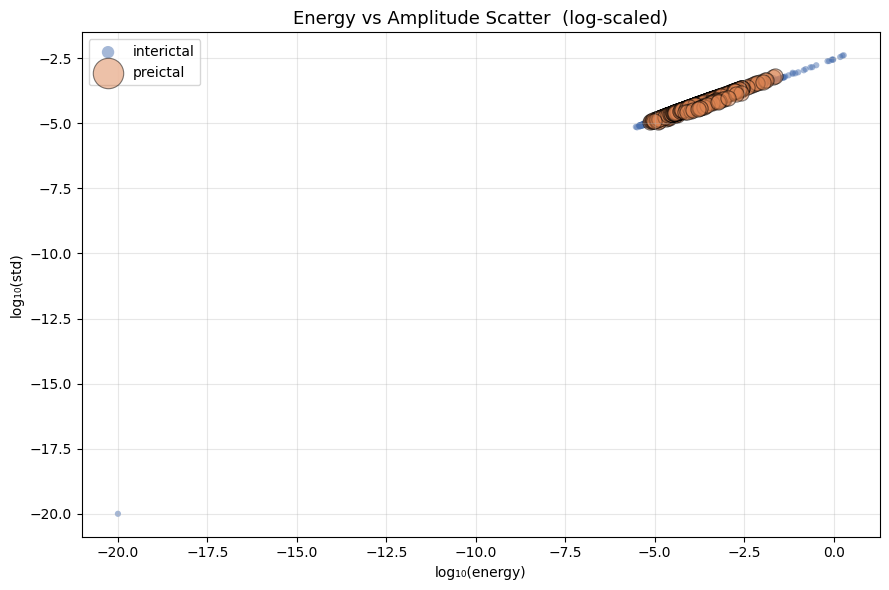

In [17]:
pre_plot = df_all[df_all["label"] == "preictal"]
intr_plot = df_all[df_all["label"] == "interictal"].sample(
    min(5000, (df_all["label"] == "interictal").sum()), random_state=42
)
scatter_df = pd.concat([pre_plot, intr_plot])

fig, ax = plt.subplots(figsize=(9, 6))
for label in LABEL_ORDER:
    sub = scatter_df[scatter_df["label"] == label]
    ax.scatter(
        np.log10(sub["energy"].clip(lower=1e-20)),
        np.log10(sub["std"].clip(lower=1e-20)),
        c=PALETTE[label],
        label=label,
        alpha=0.5,
        s=20 if label == "interictal" else 120,
        edgecolors="black" if label == "preictal" else "none",
        linewidths=0.8,
    )
ax.set_xlabel("log₁₀(energy)")
ax.set_ylabel("log₁₀(std)")
ax.set_title("Energy vs Amplitude Scatter  (log-scaled)", fontsize=13)
ax.legend(markerscale=2)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

The single pre-ictal epoch (circled in orange) sits at the high-energy, high-amplitude corner of the interictal cloud — plausible as a pre-seizure signal elevation — but meaningful 2D class separation analysis requires substantially more labeled pre-ictal data.

## Step 4: Data Preparation and Train/Test Split
This step selects features for model training and identifies the target label. The selected features include statistical, temporal, spectral, and complexity-based EEG measurements extracted from each signal window. Additionally the data is split based on subject_id, which avoids data leakage and produces more realistic model results. 

In [20]:
target_col = "target"
subject_col = "subject_id"

feature_cols = [
    "mean",
    "std",
    "min",
    "max",
    "range",
    "median",
    "iqr",
    "energy",
    "rms",
    "abs_mean",
    "peak_to_peak",
    "skewness",
    "kurtosis",
    "line_length",
    "zero_crossing_rate",
    "hjorth_activity",
    "hjorth_mobility",
    "hjorth_complexity",
    "delta_power",
    "theta_power",
    "alpha_power",
    "beta_power",
    "gamma_power",
    "rel_delta_power",
    "rel_theta_power",
    "rel_alpha_power",
    "rel_beta_power",
    "rel_gamma_power",
    "spectral_entropy",
]

# feature and target label
X = df_all[feature_cols].copy()
y = df_all[target_col].copy()
groups = df_all[subject_col].copy()

print("Using features:", feature_cols)
print("Unique subjects:", groups.nunique())

# This section splits data into train/test
gss = GroupShuffleSplit(n_splits=1, test_size=0.3, random_state=42)

# splits rows into train/test based on subject_id, this prevents data leakage
train_rows, test_rows = next(gss.split(X, y, groups=groups))

X_train = X.iloc[train_rows]
X_test = X.iloc[test_rows]

y_train = y.iloc[train_rows]
y_test = y.iloc[test_rows]

groups_train = groups.iloc[train_rows]
groups_test = groups.iloc[test_rows]

print("Shared subjects:", len(set(groups_train).intersection(set(groups_test))))

Using features: ['mean', 'std', 'min', 'max', 'range', 'median', 'iqr', 'energy', 'rms', 'abs_mean', 'peak_to_peak', 'skewness', 'kurtosis', 'line_length', 'zero_crossing_rate', 'hjorth_activity', 'hjorth_mobility', 'hjorth_complexity', 'delta_power', 'theta_power', 'alpha_power', 'beta_power', 'gamma_power', 'rel_delta_power', 'rel_theta_power', 'rel_alpha_power', 'rel_beta_power', 'rel_gamma_power', 'spectral_entropy']
Unique subjects: 35
Shared subjects: 0


## Step 5: Model Training
This step trains the Random Forest model and performs hyperparameter tuning using GridSearchCV. The random forest model is optimized using recall scoring and a balanced subsample to address class imbalance between preictal and interictal samples.

In [21]:
train_classes = np.unique(y_train)

if len(train_classes) < 2:
    print(f"WARNING: training set only contains class(es) {train_classes.tolist()}.")
    print(
        "GridSearchCV with recall scoring requires both classes — skipping grid search."
    )
    print("Add more EDF recordings with seizure annotations for hyperparameter tuning.")
    rf_model = RandomForestClassifier(
        class_weight="balanced_subsample", random_state=42, n_jobs=-1
    )
    rf_model.fit(X_train, y_train)
    print("Fitted default RandomForest without grid search.")
else:
    param_grid = {
        "n_estimators": [200, 500],
        "max_depth": [10, 20],
        "min_samples_leaf": [1, 5],
    }

    rf = RandomForestClassifier(
        class_weight="balanced_subsample", random_state=42, n_jobs=-1
    )

    grid = GridSearchCV(
        rf,
        param_grid,
        scoring="recall",
        cv=3,
        n_jobs=10,
        verbose=2,
    )

    grid.fit(X_train, y_train)
    rf_model = grid.best_estimator_
    print("Best params:", grid.best_params_)

Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best params: {'max_depth': 10, 'min_samples_leaf': 5, 'n_estimators': 200}


## Step 6: Model Evaluation
This step evaluates the Random Forest model on the test set. Predictions and class probabilities are used to calculate performance metrics and generate a performance summary. The results show that the model struggles with seizure recall despite hyperparameter tuning.

In [22]:
# Random Forest
print("\nRandom Forest")

y_pred_rf = rf_model.predict(X_test)

proba_matrix = rf_model.predict_proba(X_test)
if proba_matrix.shape[1] < 2:
    print(
        "WARNING: model only saw one class during training — dataset has too few preictal samples."
    )
    y_proba_rf = np.zeros(len(X_test))
else:
    y_proba_rf = proba_matrix[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred_rf))

if len(np.unique(y_test)) > 1:
    print("ROC AUC:", roc_auc_score(y_test, y_proba_rf))
else:
    print("ROC AUC: N/A (only one class in test set)")

cm_rf = confusion_matrix(y_test, y_pred_rf)
print("\nConfusion Matrix:")
print(cm_rf)

if cm_rf.size == 4:
    tn, fp, fn, tp = cm_rf.ravel()
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    print(f"TN: {tn}, FP: {fp}, FN: {fn}, TP: {tp}")
    print("Seizure Recall:", recall)
else:
    print("Warning: Only one class present in test set. Confusion matrix is degenerate")

print("\nPerformance summary:")
print(classification_report(y_test, y_pred_rf, zero_division=0))


Random Forest
Accuracy: 0.8301499834272457
ROC AUC: 0.5626215101457086

Confusion Matrix:
[[80129 16365]
 [   33    17]]
TN: 80129, FP: 16365, FN: 33, TP: 17
Seizure Recall: 0.34

Performance summary:
              precision    recall  f1-score   support

           0       1.00      0.83      0.91     96494
           1       0.00      0.34      0.00        50

    accuracy                           0.83     96544
   macro avg       0.50      0.59      0.45     96544
weighted avg       1.00      0.83      0.91     96544



## Step 7: Threshold Tuning
This step performs automatic threshold tuning on the Random Forest model to prioritize a seizure recall target of 0.50. Multiple probability thresholds are evaluated to identify a better balance between seizure recall and false positives. The final evaluation shows that increasing seizure recall also increases the number of false positives.

In [23]:
if len(np.unique(y_test)) < 2:
    print("Skipping threshold tuning: only one class present in test set.")
    print("Add more EDF recordings with seizure annotations to enable this analysis.")
else:
    print("\nAutomatic Threshold Search")

    thresholds = np.linspace(0.01, 0.99, 100)
    rows = []

    for t in thresholds:
        y_pred_t = (y_proba_rf >= t).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_test, y_pred_t).ravel()

        rows.append(
            {
                "threshold": t,
                "accuracy": accuracy_score(y_test, y_pred_t),
                "precision": precision_score(y_test, y_pred_t, zero_division=0),
                "recall": recall_score(y_test, y_pred_t, zero_division=0),
                "f1": f1_score(y_test, y_pred_t, zero_division=0),
                "TN": tn,
                "FP": fp,
                "FN": fn,
                "TP": tp,
            }
        )

    threshold_df = pd.DataFrame(rows)
    display(threshold_df.sort_values("recall", ascending=False).head(10))

    target_recall = 0.50
    candidates = threshold_df[threshold_df["recall"] >= target_recall]

    if len(candidates) > 0:
        best_row = candidates.sort_values("FP").iloc[0]
    else:
        best_row = threshold_df.sort_values("recall", ascending=False).iloc[0]

    best_threshold = best_row["threshold"]

    print("\nSelected Threshold")
    print(best_row)

    print("\nFinal Evaluation (Best Threshold)")
    y_pred_best = (y_proba_rf >= best_threshold).astype(int)

    print("Threshold:", best_threshold)
    print("Accuracy:", accuracy_score(y_test, y_pred_best))
    print("ROC AUC:", roc_auc_score(y_test, y_proba_rf))

    cm_best = confusion_matrix(y_test, y_pred_best)
    print("\nConfusion Matrix:")
    print(cm_best)

    tn, fp, fn, tp = cm_best.ravel()
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    print(f"TN: {tn}, FP: {fp}, FN: {fn}, TP: {tp}")
    print("Seizure Recall:", recall)

    print("\nPerformance summary:")
    print(classification_report(y_test, y_pred_best, zero_division=0))


Automatic Threshold Search


,threshold,accuracy,precision,recall,f1,TN,FP,FN,TP
0,0.010000,0.002444,0.000509,0.98,0.001017,187,96307,1,49
1,0.019899,0.013165,0.000483,0.92,0.000965,1225,95269,4,46
2,0.029798,0.036284,0.000473,0.88,0.000945,3459,93035,6,44
3,0.039697,0.060397,0.000463,0.84,0.000925,5789,90705,8,42
4,0.049596,0.081372,0.000473,0.84,0.000946,7814,88680,8,42
5,0.059495,0.107464,0.000487,0.84,0.000974,10333,86161,8,42
6,0.069394,0.133804,0.000502,0.84,0.001003,12876,83618,8,42
7,0.079293,0.160745,0.000506,0.82,0.001011,15478,81016,9,41
8,0.089192,0.188287,0.000510,0.80,0.001020,18138,78356,10,40
9,0.099091,0.215850,0.000515,0.78,0.001029,20800,75694,11,39



Selected Threshold
threshold        0.316869
accuracy         0.620132
precision        0.000709
recall           0.520000
f1               0.001416
TN           59844.000000
FP           36650.000000
FN              24.000000
TP              26.000000
Name: 31, dtype: float64

Final Evaluation (Best Threshold)
Threshold: 0.31686868686868686
Accuracy: 0.6201317533974147
ROC AUC: 0.5626215101457086

Confusion Matrix:
[[59844 36650]
 [   24    26]]
TN: 59844, FP: 36650, FN: 24, TP: 26
Seizure Recall: 0.52

Performance summary:
              precision    recall  f1-score   support

           0       1.00      0.62      0.77     96494
           1       0.00      0.52      0.00        50

    accuracy                           0.62     96544
   macro avg       0.50      0.57      0.38     96544
weighted avg       1.00      0.62      0.77     96544

